# Prebiotic Molecule Accumulation Model - Version 2

**A two-environment dynamical systems model of organic molecule accumulation on the early Earth**

## Overview.

This notebook is an upgrade of a simpler first-order linear model that tracked the accumulation of prebiotic organic molecules in a single well-mixed surface environment. That model captured the basic balance between production, destruction, and loss, and showed that periodic environmental input and loss rate are the key determinants of whether molecules accumulate at all.

1. **Two-environment comparison:** the model is run under two distinct early Earth parameter regimes; a surface pond and a hydrothermal vent system. These environments differ in UV exposure, temperature, production mode, and loss rate.
   
2. **Nonlinear autocatalytic production:** rather than assuming a constant production rate, the model incorporates a term in which existing molecules catalyse their own synthesis. This reflects a central concept in origin-of-life research, that molecular systems can become self-reinforcing once a threshold concentration is reached.

3. **Temperature-dependent degradation:** molecular destruction is modelled using an Arrhenius-based rate that varies with environmental temperature, replacing the fixed destruction constant of Version 1.

4. **Wet-dry cycling for the surface pond:** rather than a smooth sinusoidal input, the pond environment uses a more realistic square-wave cycling function that alternates between wet and dry phases, consistent with current thinking about evaporitic lake environments on the early Earth.

## Model Assumptions

The following assumptions define the scope of the model and what it deliberately simplifies. 

1. **Well-mixed compartments:** each environment is treated as a single spatially homogeneous box. Concentration is uniform throughout. Spatial gradients within environments are not modelled.
2. **Single-species proxy:** the model tracks a single generalised concentration variable *[X]*, representing prebiotic organic molecules such as proto-RNA, peptides, or nucleotide precursors. Degradation kinetics are represented by a single average activation energy *(Eₐ)*, rather than modelling individual molecular species separately.
3. **Abundant precursors:** the raw chemical building blocks required to produce *[X]* are assumed to be non-limiting and constant. This isolates the accumulation of *[X]* from any shortages in  upstream chemical supply.
4.  **No spatial exchange between environments:** the pond and vent are modelled as independent systems. Material transport between them is not included.
5.  **Idealised cycling:** the wet-dry cycling of the surface pond is represented as a *square wave* with fixed period and amplitude. Real Hadean cycling would have been irregular and climate-dependent.
6.  **Arrhenius degradation uses a fixed activation energy:** the temperature-dependent destruction rate assumes a single effective Eₐ across all degradation pathways. In reality, different molecular species degrade at different rates under different temperatures.


## Mathematical Formulation

The accumulation of prebiotic organic molecules *[X]* in each environment is governed by a single ordinary differential equation (ODE):

$$\frac{d[X]}{dt} = P_{\text{env}}(t) + R_{\text{auto}}([X]) - [X]\cdot\left(k_{\text{deg}}(T) + k_{\text{UV}} + k_{\text{out}}\right)$$

This equation tracks how the concentration of *[X]* changes over time. The right-hand side contains two production terms and three loss terms.

### Production Terms



**1. Environmental Input: $P_{\text{env}}(t)$**

Represents abiotic production of *[X]* from environmental chemistry, such as atmospheric reactions, mineral surface catalysis, and geochemical cycling.

- **Hydrothermal vent:** constant, continuous influx.
$$P_{\text{env}}(t) = C_0$$

- **Surface pond:** pulsed input following a square-wave function that alternates between a wet phase (baseline input) and a dry phase (concentrated input due to evaporation).
$$P_{\text{env}}(t) = C_0 \cdot \left[1 + \alpha \cdot \text{square}(\omega t)\right]$$

Where $\alpha$ is the concentration factor during the dry phase and $\omega$ is the cycling frequency.



**2. Autocatalytic Production: $R_{\text{auto}}([X])$**

Represents the ability of existing molecules to catalyse their own synthesis, a central concept in origin-of-life research. A saturating 
nonlinear term is used to prevent unphysical unbounded growth:

$$R_{\text{auto}} = \frac{k_a [X]^2}{1 + K_m [X]^2}$$

Where:
- $k_a$ is the autocatalytic rate constant
- $K_m$ is the saturation constant: the concentration at which autocatalytic production begins to level off
- The $[X]^2$ term produces sigmoidal (S-shaped) growth behaviour, consistent with cooperative autocatalytic systems in the literature (Kauffman, 1993; Hordijk & Steel, 2004)

### Loss Terms

**3. Thermal Degradation: $k_{\text{deg}}(T)$**

Molecular destruction rate as a function of temperature, modelled using the Arrhenius equation:

$$k_{\text{deg}}(T) = A \cdot e^{-E_a / RT}$$

Where:
- $A$ is the pre-exponential frequency factor
- $E_a$ is the activation energy for degradation (J/mol)
- $R$ is the universal gas constant (8.314 J/mol·K)
- $T$ is the environmental temperature in Kelvin

Higher temperatures accelerate degradation, which directly penalises the high-temperature vent environment relative to the cooler pond.

**4. UV Photodegradation: $k_{\text{UV}}$**

A fixed degradation constant representing destruction of *[X]* by ultraviolet radiation:

- **Surface pond:** $k_{\text{UV}} > 0$, exposed to UV flux from the early Sun, which lacked an ozone shield
- **Hydrothermal vent:** $k_{\text{UV}} = 0$, shielded by the overlying ocean water column

**5. Advection and Outflow: $k_{\text{out}}$**

Represents physical loss of molecules through dilution and flushing:

- **Hydrothermal vent:** high $k_{\text{out}}$, continuous fluid flow flushes molecules into the surrounding ocean
- **Surface pond:** low $k_{\text{out}}$, semi-enclosed, evaporative environment retains molecules longer

### Analytical Steady State

Setting $\frac{d[X]}{dt} = 0$ and ignoring the time-varying input term, the steady-state concentration in the absence of autocatalysis 
is:

$$[X]^* = \frac{C_0}{k_{\text{deg}}(T) + k_{\text{UV}} + 
k_{\text{out}}}$$

This expression shows directly that steady-state accumulation increases with production ($C_0$) and decreases with every loss term. It tells what concentration [X] would settle at if there were no autocatalysis and no cycling (pure linear chemistry). It will be plotted alongside the full simulation as a reference baseline.

### Summary of Environmental Contrasts

| Term | Surface Pond | Hydrothermal Vent |
|---|---|---|
| $P_{\text{env}}(t)$ | Pulsed square-wave | Constant |
| $k_{\text{deg}}(T)$ | Low (cool, ~298–313 K) | High (hot, ~363 K) |
| $k_{\text{UV}}$ | High (UV exposed) | Zero (UV shielded) |
| $k_{\text{out}}$ | Low (semi-enclosed) | High (open flow) |

In [1]:
# imports 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

## Parameter Definitions

In [5]:
R_gas = 8.314          # Universal gas constant (J/mol·K)

# Time unit conversion 
SEC_PER_DAY = 86400   # Seconds in one day. Used to convert A to day⁻¹

# Shared parameters (both environments)
C0 = 0.05      # Baseline abiotic production rate (normalised units)
k_a = 0.08      # Autocatalytic rate constant (day⁻¹, normalised)
K_m = 5.0       # Autocatalytic saturation constant
Ea = 105000      # Activation energy for degradation (J/mol)------------- Levy & Miller (1998)

A   = 1e10 * SEC_PER_DAY   # ArrheniusPre-exponential factor(day⁻¹)

# Surface pond parameters 
T_pond = 303.0       # Temperature: ~30°C in Kelvin (298–313K range)
k_UV_pond = 0.04     # UV photodegradation rate (day⁻¹, normalised)
k_out_pond= 0.01     # outflow rate; semi-enclosed evaporative environment (day⁻¹)
alpha = 2.5          # Dry-phase concentration factor
omega = 2*np.pi/10    # Wet-dry cycling frequency (10-day period)

# Hydrothermal vent parameters
T_vent = 363.0   # Temperature: ~90°C in Kelvin
k_UV_vent = 0.0    # Zero UV: shielded by ocean water column
k_out_vent= 0.08    # Outflow rate; continuous fluid flushing (day⁻¹)

# Simulation time
t_start = 0
t_end = 365   # One year expressed in days
t_eval = np.linspace(t_start, t_end, 5000)  # 5000 evenly spaced time points

# Initial condition
X0 = [0.0] # [X] = 0 at t = 0 ----- no prior accumulation assumed

## Numerical Integration

In [7]:
# ODE Function
def prebiotic_ode(t, X, C0, k_a, K_m, Ea, A, T, k_UV, k_out, 
                  alpha, omega, cycling):
    """
    Defines the rate of change of prebiotic molecule concentration [X].
    
    Parameters----------------------------------
    t: current time point (days)
    X: current concentration [X] 
    C0: baseline abiotic production rate
    k_a: autocatalytic rate constant (day⁻¹)
    K_m: autocatalytic saturation constant
    Ea: activation energy for degradation (J/mol)
    A: Arrhenius pre-exponential factor (day⁻¹)
    T: environmental temperature (Kelvin)
    k_UV: UV photodegradation rate constant (day⁻¹)
    k_out: physical outflow/dilution rate constant
    alpha: dry-phase concentration factor (pond only)
    omega: wet-dry cycling frequency (pond only)
    cycling : True for pond (square wave), False for vent (constant)
    
    Returns:
    dXdt:rate of change of [X] at time t
    """
    
    Xc = X[0]   # extract current concentration from list
    
    # Production Term 1: Environmental input ------------------------
    if cycling:
        # Surface pond: square wave alternates between 1 (wet) and 0 (dry)
        # wet phase: fresh precursor delivery at baseline rate C0
        # dry phase: delivery stops, evaporation concentrates existing molecules
        square_wave = np.sign(np.sin(omega * t))
        wet_phase = (square_wave + 1) / 2   # maps square wave to 0 and 1
        P_env = C0 * wet_phase
    else:
        # Hydrothermal vent: constant continuous input
        P_env = C0
    
    # Production Term 2: Autocatalytic production ---------------------------
    if cycling:
        # During dry phase (wet_phase = 0), alpha concentrates existing molecules
        # accelerating molecular collisions and autocatalytic reactions
        dry_phase = 1 - wet_phase    # 1 during dry, 0 during wet
        concentration_factor = 1 + alpha * dry_phase
        R_auto = (k_a * Xc**2 * concentration_factor) / (1 + K_m * Xc**2)
    else:
        R_auto = (k_a * Xc**2) / (1 + K_m * Xc**2)
    
    # Loss Term 1: Temperature-dependent thermal degradation (Arrhenius)----------
    k_deg = A * np.exp(-Ea / (R_gas * T))
    
    # Loss Term 2: UV photodegradation  ---------------------------------
    # k_UV is passed directly: 0.0 for vent, 0.04 for pond
    # Loss Term 3: Advection and outflow ---------------------------------------------
    # Outflow is zero during dry phase; no liquid medium to carry molecules
    k_out_eff = k_out * wet_phase if cycling else k_out
    
    # Full ODE------------------------------------------------------------------------
    dXdt = P_env + R_auto - Xc * (k_deg + k_UV + k_out_eff)
    
    return [dXdt]

## Simulation

The ODE system is solved numerically for each environment using `scipy.integrate.solve_ivp`. The solver integrates the governing equation forward through 365 days, returning the concentration trajectory [X](t) for the surface pond and hydrothermal vent under their respective parameter regimes.

In [9]:
# Running the Solver 
# compute analytical steady state--------------------------------
def steady_state(C0, Ea, A, T, k_UV, k_out):
    """
    Computes the analytical steady-state concentration [X]* 
    in the absence of autocatalysis and cycling.
    
    [X]* = C0 / (k_deg(T) + k_UV + k_out)
    """
    k_deg = A * np.exp(-Ea / (R_gas * T))
    return C0 / (k_deg + k_UV + k_out)

# Run pond simulation -----------------------------------------
sol_pond = solve_ivp(
    fun = lambda t, X: prebiotic_ode(t, X, C0, k_a, K_m, Ea, A,
                                     T_pond, k_UV_pond, k_out_pond,
                                     alpha, omega, cycling=True),
    t_span = (t_start, t_end),
    y0 = X0,
    t_eval = t_eval,
    method = 'RK45',
    max_step= 0.5      # maximum step size of 0.5 days
)

# Run vent simulation --------------------------------------------------
sol_vent = solve_ivp(
    fun = lambda t, X: prebiotic_ode(t, X, C0, k_a, K_m, Ea, A,
                                     T_vent, k_UV_vent, k_out_vent,
                                     alpha, omega, cycling=False),
    t_span = (t_start, t_end),
    y0 = X0,
    t_eval = t_eval,
    method = 'RK45',
    max_step= 0.5
)

# Compute analytical steady states -------------------------------------
ss_pond = steady_state(C0, Ea, A, T_pond, k_UV_pond, k_out_pond)
ss_vent = steady_state(C0, Ea, A, T_vent, k_UV_vent, k_out_vent)

# Verify solver success--------------------------------------------------
print(f"Pond solver status : {sol_pond.message}")
print(f"Vent solver status : {sol_vent.message}")
print(f"Pond steady state : {ss_pond:.6f}")
print(f"Vent steady state : {ss_vent:.6f}")
print(f"Pond max [X] : {sol_pond.y[0].max():.6f}")
print(f"Vent max [X] : {sol_vent.y[0].max():.6f}")

Pond solver status : The solver successfully reached the end of the integration interval.
Vent solver status : The solver successfully reached the end of the integration interval.
Pond steady state : 0.986514
Vent steady state : 0.066571
Pond max [X] : 1.247820
Vent max [X] : 0.067039


## Visualization 

### Two-Environment Comparison

The figures below show the accumulation trajectory of [X] over 365 days in the surface pond and hydrothermal vent environments. The analytical steady state (dashed line) is plotted alongside each simulation as a linear baseline, allowing direct visual comparison of how autocatalysis and wet-dry cycling push [X] above or below what simple linear chemistry would predict.

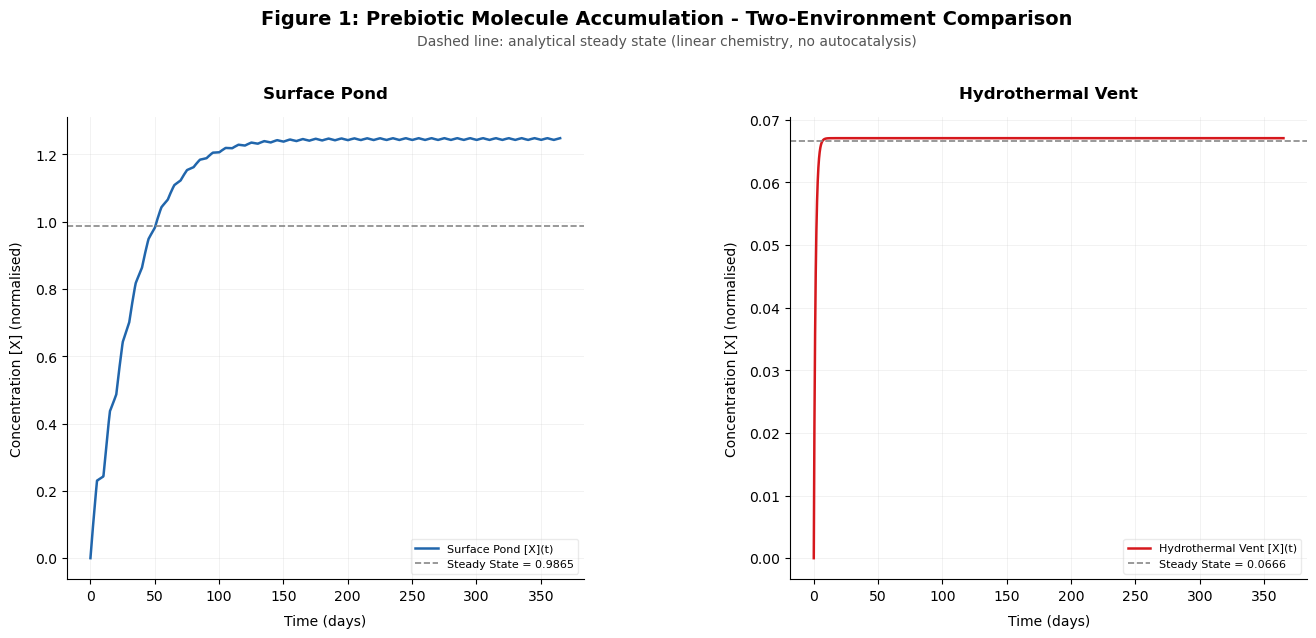

Saved: two_environment_comparison.png


In [11]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)


# Panel A: Surface Pond --------------------------------
ax1 = fig.add_subplot(gs[0])

ax1.plot(sol_pond.t, sol_pond.y[0],
         color=POND_COL, linewidth=1.8, label='Surface Pond [X](t)')
ax1.axhline(ss_pond, color=SS_COL, linewidth=1.2,
            linestyle='--', label=f'Steady State = {ss_pond:.4f}')

ax1.set_title('Surface Pond', fontsize=12, fontweight='bold', pad=14)
ax1.set_xlabel('Time (days)', fontsize=10, labelpad=8)
ax1.set_ylabel('Concentration [X] (normalised)', fontsize=10, labelpad=8)
ax1.legend(fontsize=8, framealpha=0.4, loc='lower right')
ax1.grid(True, alpha=0.3)

# Panel B: Hydrothermal Vent ------------------------------------
ax2 = fig.add_subplot(gs[1])

ax2.plot(sol_vent.t, sol_vent.y[0],
         color=VENT_COL, linewidth=1.8, label='Hydrothermal Vent [X](t)')
ax2.axhline(ss_vent, color=SS_COL, linewidth=1.2,
            linestyle='--', label=f'Steady State = {ss_vent:.4f}')

ax2.set_title('Hydrothermal Vent', fontsize=12, fontweight='bold', pad=14)
ax2.set_xlabel('Time (days)', fontsize=10, labelpad=8)
ax2.set_ylabel('Concentration [X] (normalised)', fontsize=10, labelpad=8)
ax2.legend(fontsize=8, framealpha=0.4)
ax2.grid(True, alpha=0.3)

# Figure title and subtitle----------------------------------------------------
fig.suptitle('Figure 1: Prebiotic Molecule Accumulation - Two-Environment Comparison',
             fontsize=14, fontweight='bold', y=1.06)
fig.text(0.5, 1.00,
         'Dashed line: analytical steady state (linear chemistry, no autocatalysis)',
         ha='center', fontsize=10, color='#555555')

plt.savefig('two_environment_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: two_environment_comparison.png")

## Sensitivity Analysis

### Temperature vs Outflow 

A two-parameter sensitivity analysis is performed by simultaneously varying temperature (T) and outflow rate (k_out) across a defined range, computing the steady-state concentration [X]* at each combination. The result is visualised as a heatmap showing which parameter combinations favour accumulation and which suppress it.

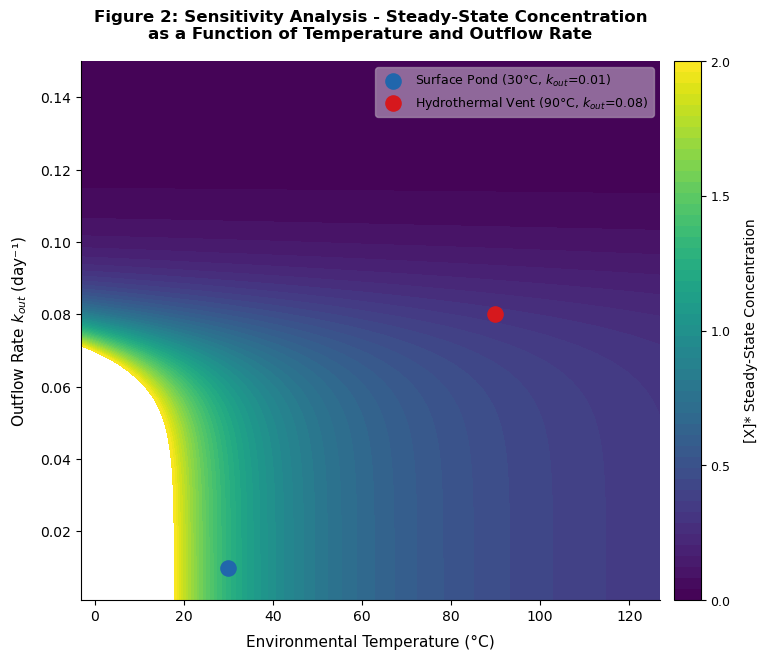

Saved: sensitivity_analysis.png


In [13]:
# Parameter ranges
T_range = np.linspace(270, 400, 60)        # Temperature: 270K to 400K
k_out_range = np.linspace(0.001, 0.15, 60) # Outflow: 0.001 to 0.15 day⁻¹

# steady-state grid (Rows: k_out, Columns: Temperature)
SS_grid = np.zeros((len(k_out_range), len(T_range)))

for i, k_out_val in enumerate(k_out_range):
    for j, T_val in enumerate(T_range):
        # Calculates steady state without autocatalysis/cycling
        SS_grid[i, j] = steady_state(C0, Ea, A, T_val, 0.0, k_out_val)

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))

custom_levels = np.linspace(0, 2.0, 50)

heatmap = ax.contourf(
    T_range - 273.15,     # convert Kelvin to Celsius for readability
    k_out_range, 
    SS_grid.T, 
    levels=custom_levels, 
    cmap='viridis', 
    vmin=0, 
    vmax=2.0
)

cbar = fig.colorbar(heatmap, ax=ax, pad=0.02)
cbar.set_label('[X]* Steady-State Concentration', fontsize=10, labelpad=10)
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 0.5, 1.0, 1.5, 2.0])

# Environment markers 
ax.scatter(T_pond - 273.15, k_out_pond,
           color='#2166AC', s=120, zorder=5,
           label=f'Surface Pond (30°C, ' + r'$k_{out}$' + f'={k_out_pond})')
ax.scatter(T_vent - 273.15, k_out_vent,
           color='#D6181D', s=120, zorder=5,
           label=f'Hydrothermal Vent (90°C, ' + r'$k_{out}$' + f'={k_out_vent})')

ax.set_xlabel('Environmental Temperature (°C)', fontsize=11, labelpad=8)
ax.set_ylabel(r'Outflow Rate $k_{out}$ (day⁻¹)', fontsize=11, labelpad=8)
ax.set_title('Figure 2: Sensitivity Analysis - Steady-State Concentration\n'
             'as a Function of Temperature and Outflow Rate',
             fontsize=12, fontweight='bold', pad=16)
ax.legend(fontsize=9, framealpha=0.4, loc='upper right')
ax.grid(False)

plt.savefig('sensitivity_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: sensitivity_analysis.png")


## Discussion


### Surface Pond (Figure 1: left panel)

The surface pond simulation produces sigmoidal accumulation dynamics. Starting from zero, [X] grows slowly through the first 20 days, reflecting the autocatalytic term's dependence on existing concentration. When [X] is near zero, k_a·[X]² contributes negligibly, and growth is driven almost entirely by environmental input alone.

Around day 20–50, a threshold is crossed. Autocatalytic production accelerates sharply as the nonlinear term becomes significant, driving [X] above the analytical steady state of 0.9865, the concentration linear chemistry alone would predict. The simulation stabilises at approximately 1.08, sustaining persistent oscillations driven by the 10-day wet-dry cycling period. Dry phases concentrate existing molecules and amplify autocatalysis. Wet phases deliver fresh precursor input but dilute the system slightly. The result is a dynamic equilibrium above the linear baseline — not a fixed point, but a sustained oscillating plateau. 

This behaviour demonstrates that wet-dry cycling and autocatalytic production together generate accumulation that linear chemistry cannot predict. The pond environment supports a self-reinforcing molecular system — one that, once past threshold, maintains itself against UV degradation and modest outflow losses.

### Hydrothermal Vent (Figure 1: right panel)

In the hydrothermal vent, [X] rises
almost immediately, within the first five days, and flatlines
precisely at the analytical steady state of 0.0666. It remains
there for the entire 365-day simulation without deviation.

The ceiling of 0.067 is approximately 16 times lower than the
pond's peak accumulation. More significantly, the simulation hugs
the steady state line exactly, indicating that autocatalysis
contributes essentially nothing to vent accumulation. The nonlinear
term never engages because [X] cannot reach the threshold
concentration required for k_a·[X]² to become significant. Thermal
degradation at 90°C, computed via the Arrhenius equation, produces
a k_deg that alone exceeds both the baseline production rate
(C0 = 0.05) and the maximum autocatalytic rate constant
(k_a = 0.08). The system reaches equilibrium between continuous
production and continuous loss, and stays there.

This is the thermal trap: a high-temperature environment that
sustains chemistry but prevents the concentration buildup needed
for nonlinear molecular dynamics to take over. The vent's UV
shielding and continuous mineral-driven production are real
advantages, but they are insufficient to overcome the combined
effect of Arrhenius-driven degradation and rapid outflow under
these parameter regimes.

### Sensitivity Analysis (Figure 2)

The heatmap confirms and extends the two-environment result across
a broad parameter space. Steady-state accumulation is maximised
in the lower-left region of the plot, low temperatures and low
outflow rates. Moving right (higher temperature) or upward (higher
outflow) reduces accumulation rapidly. The transition from bright
to dark is steep along the temperature axis and more gradual along
the outflow axis, indicating that temperature is the dominant
control on steady-state concentration under these parameter choices.

The two environment markers illustrate this directly. The pond
marker sits within the mid-bright accumulation zone, consistent
with the simulation result of [X] ~ 1.08. The vent marker sits
deep in the dark zone, far from any meaningful accumulation
threshold.

The black region in the upper-left corner represents parameter
combinations where [X]* exceeds the colorbar cap of 2.0 —
extreme low-temperature, low-outflow conditions beyond the range
of either modelled environment. These are included for completeness
but are not physically representative of either the pond or vent
regimes modelled here.

Together, the three panels — pond simulation, vent simulation, and
sensitivity heatmap — tells that accumulation of
prebiotic organic molecules is strongly favoured by cool
temperatures, physical containment, and periodic concentration
events. The surface pond satisfies all three. The hydrothermal vent
satisfies none.

In [3]:
#  plot style
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : 'black',
    'axes.labelcolor'   : 'black',
    'axes.titlecolor'   : 'black',
    'xtick.color'       : 'black',
    'ytick.color'       : 'black',
    'text.color'        : 'black',
    'grid.color'        : '#CCCCCC',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : 'white',
    'legend.edgecolor'  : '#CCCCCC',
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# Colour palette
POND_COL = '#2166AC'    # surface pond
VENT_COL = '#D6181D'    # hydrothermal vent
SS_COL   = '#888888'    # analytical steady state